# Forecast Spasial 1 Bulan - Gempa M>=3 dari Klik Lat/Lon
Notebook ini adalah versi baru untuk kebutuhan inferensi berbasis lokasi klik peta.

Output utama inferensi: 
- probabilitas minimal 1 gempa M>=3 bulan depan pada cell lokasi klik
- ekspektasi jumlah gempa M>=3 bulan depan pada cell lokasi klik

## Alur
1. Load katalog gempa
2. Filter magnitude >= 3.0
3. Ubah koordinat ke grid spasial (cell)
4. Bentuk panel bulanan per cell
5. Feature engineering lag + musiman
6. Train two-stage model:
   - Classifier: probabilitas ada kejadian
   - Regressor: jumlah kejadian jika terjadi
7. Evaluasi pada 12 bulan terakhir
8. Retrain full data dan simpan model
9. Inferensi 1 bulan ke depan dari input klik lat/lon

In [23]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, brier_score_loss, roc_auc_score

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

MAG_THRESHOLD = 3.0
GRID_DEG = 1.0
TEST_HORIZON = 12
LAGS = [1, 2, 3, 6, 12]
ROLL_WINDOWS = [3, 6, 12]

PROJECT_ROOT = Path(r"D:\Projects\bencana_dicoding_app")
DATA_PATH = PROJECT_ROOT / 'data_gempa_kaggle/katalog_gempa_v2.tsv'
ARTIFACT_DIR = Path(r"D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3")
MODEL_DIR = ARTIFACT_DIR / 'saved_models'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'File data tidak ditemukan: {DATA_PATH}')

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('CWD:', Path.cwd().resolve())
print('Project root:', PROJECT_ROOT)
print('Data path:', DATA_PATH)
print('Artifact dir:', ARTIFACT_DIR)
print('Grid size (deg):', GRID_DEG)

CWD: D:\Projects\bencana_dicoding_app\timeseries_triwulan
Project root: D:\Projects\bencana_dicoding_app
Data path: D:\Projects\bencana_dicoding_app\data_gempa_kaggle\katalog_gempa_v2.tsv
Artifact dir: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3
Grid size (deg): 1.0


In [24]:
# Load data dan filter M>=3
df = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
df = df.dropna(subset=['datetime', 'magnitude', 'latitude', 'longitude']).copy()
df['datetime'] = df['datetime'].dt.tz_convert(None)

df_m3 = df[df['magnitude'] >= MAG_THRESHOLD].copy()
df_m3['month'] = df_m3['datetime'].dt.to_period('M').dt.to_timestamp()

latest_dt = df_m3['datetime'].max()
latest_month_start = latest_dt.to_period('M').to_timestamp()
days_in_latest_month = latest_dt.to_period('M').days_in_month
latest_month_is_complete = latest_dt.day >= days_in_latest_month

excluded_incomplete_month = None
if not latest_month_is_complete:
    excluded_incomplete_month = latest_month_start
    df_m3 = df_m3[df_m3['month'] < latest_month_start].copy()

if df_m3.empty:
    raise ValueError('Semua data tersaring setelah buang bulan terakhir yang belum lengkap.')

df_m3['lat_bin'] = np.floor(df_m3['latitude'] / GRID_DEG).astype(int)
df_m3['lon_bin'] = np.floor(df_m3['longitude'] / GRID_DEG).astype(int)

print('Raw rows:', len(df))
print('Rows M>=3 (setelah filter completeness):', len(df_m3))
if excluded_incomplete_month is not None:
    print('Excluded incomplete latest month:', excluded_incomplete_month.date(), '| last timestamp in source:', latest_dt)
print('Month range:', df_m3['month'].min(), '->', df_m3['month'].max())
print('Unique spatial cells:', df_m3[['lat_bin', 'lon_bin']].drop_duplicates().shape[0])

Raw rows: 131131
Rows M>=3 (setelah filter completeness): 93269
Excluded incomplete latest month: 2025-10-01 | last timestamp in source: 2025-10-01 09:08:34.331422
Month range: 2008-11-01 00:00:00 -> 2025-09-01 00:00:00
Unique spatial cells: 710


In [25]:
# Bentuk panel bulanan per cell
counts = (
    df_m3.groupby(['month', 'lat_bin', 'lon_bin'])
    .size()
    .rename('count_m3')
    .reset_index()
)

all_months = pd.date_range(counts['month'].min(), counts['month'].max(), freq='MS')
cells = counts[['lat_bin', 'lon_bin']].drop_duplicates().sort_values(['lat_bin', 'lon_bin']).reset_index(drop=True)
cells['cell_idx'] = np.arange(len(cells))

panel = pd.MultiIndex.from_product([all_months, cells['cell_idx']], names=['month', 'cell_idx']).to_frame(index=False)
panel = panel.merge(cells, on='cell_idx', how='left').drop(columns='cell_idx')
panel = panel.merge(counts, on=['month', 'lat_bin', 'lon_bin'], how='left')
panel['count_m3'] = panel['count_m3'].fillna(0.0).astype(float)
panel['cell_id'] = panel['lat_bin'].astype(str) + '_' + panel['lon_bin'].astype(str)
panel['lat_center'] = (panel['lat_bin'] + 0.5) * GRID_DEG
panel['lon_center'] = (panel['lon_bin'] + 0.5) * GRID_DEG

print('Panel rows:', len(panel))
print('Months:', panel['month'].nunique())
print('Cells:', panel['cell_id'].nunique())
print('Zero ratio:', round((panel['count_m3'] == 0).mean(), 4))
panel.head()

Panel rows: 144130
Months: 203
Cells: 710
Zero ratio: 0.7592


,month,lat_bin,lon_bin,count_m3,cell_id,lat_center,lon_center
0,2008-11-01,-12,111,0.0,-12_111,-11.5,111.5
1,2008-11-01,-11,100,0.0,-11_100,-10.5,100.5
2,2008-11-01,-11,101,0.0,-11_101,-10.5,101.5
3,2008-11-01,-11,102,0.0,-11_102,-10.5,102.5
4,2008-11-01,-11,103,0.0,-11_103,-10.5,103.5


In [26]:
def build_feature_table(panel_df, lags, roll_windows):
    df_feat = panel_df.sort_values(['cell_id', 'month']).copy()
    g = df_feat.groupby('cell_id')['count_m3']

    for lag in lags:
        df_feat[f'lag_{lag}'] = g.shift(lag)

    shifted = g.shift(1)
    for w in roll_windows:
        roll_mean = shifted.groupby(df_feat['cell_id']).rolling(w).mean().reset_index(level=0, drop=True)
        roll_std = shifted.groupby(df_feat['cell_id']).rolling(w).std(ddof=0).reset_index(level=0, drop=True)
        df_feat[f'roll_mean_{w}'] = roll_mean
        df_feat[f'roll_std_{w}'] = roll_std

    df_feat['month_num'] = df_feat['month'].dt.month
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month_num'] / 12.0)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month_num'] / 12.0)

    df_feat['is_event'] = (df_feat['count_m3'] > 0).astype(int)
    return df_feat

feature_table = build_feature_table(panel, LAGS, ROLL_WINDOWS)

FEATURE_COLS = (
    [f'lag_{x}' for x in LAGS]
    + [f'roll_mean_{x}' for x in ROLL_WINDOWS]
    + [f'roll_std_{x}' for x in ROLL_WINDOWS]
    + ['month_sin', 'month_cos', 'lat_bin', 'lon_bin']
)

model_df = feature_table.dropna(subset=FEATURE_COLS).copy()
print('Feature rows ready for training:', len(model_df))
model_df.head()

Feature rows ready for training: 135610


,month,lat_bin,lon_bin,count_m3,cell_id,lat_center,lon_center,lag_1,lag_2,lag_3,...,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12,month_num,month_sin,month_cos,is_event
8558,2009-11-01,-10,101,0.0,-10_101,-9.5,101.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11,-5.000000e-01,8.660254e-01,0
9268,2009-12-01,-10,101,0.0,-10_101,-9.5,101.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,12,-2.449294e-16,1.000000e+00,0
9978,2010-01-01,-10,101,0.0,-10_101,-9.5,101.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,5.000000e-01,8.660254e-01,0
10688,2010-02-01,-10,101,0.0,-10_101,-9.5,101.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2,8.660254e-01,5.000000e-01,0
11398,2010-03-01,-10,101,0.0,-10_101,-9.5,101.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3,1.000000e+00,6.123234e-17,0


In [27]:
# Split train/test berdasarkan bulan
unique_months = np.array(sorted(model_df['month'].unique()))
if len(unique_months) <= TEST_HORIZON:
    raise ValueError('Bulan data tidak cukup untuk test horizon.')

test_months = unique_months[-TEST_HORIZON:]
train_df = model_df[~model_df['month'].isin(test_months)].copy()
test_df = model_df[model_df['month'].isin(test_months)].copy()

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_train_occ = train_df['is_event']
y_test_occ = test_df['is_event']

y_train_cnt = train_df['count_m3']
y_test_cnt = test_df['count_m3']

mask_pos = y_train_cnt > 0
if mask_pos.sum() == 0:
    raise ValueError('Tidak ada sampel positif untuk melatih regressor jumlah kejadian.')

print('Train rows:', len(train_df), '| Test rows:', len(test_df))
print('Train positive rows:', int(mask_pos.sum()), '| Train positive ratio:', round(float(mask_pos.mean()), 4))

Train rows: 127090 | Test rows: 8520
Train positive rows: 31043 | Train positive ratio: 0.2443


In [28]:
# Simpan dataset train/test ke CSV untuk audit
EXPORT_COLS = ['month', 'cell_id', 'lat_bin', 'lon_bin', 'count_m3', 'is_event'] + FEATURE_COLS

train_export = train_df[EXPORT_COLS].copy()
test_export = test_df[EXPORT_COLS].copy()

train_export.to_csv(ARTIFACT_DIR / 'train_dataset_spatial.csv', index=False)
test_export.to_csv(ARTIFACT_DIR / 'test_dataset_spatial.csv', index=False)

print('Saved train dataset:', ARTIFACT_DIR / 'train_dataset_spatial.csv')
print('Saved test dataset:', ARTIFACT_DIR / 'test_dataset_spatial.csv')
print('Train shape:', train_export.shape)
print('Test shape:', test_export.shape)

Saved train dataset: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\train_dataset_spatial.csv
Saved test dataset: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\test_dataset_spatial.csv
Train shape: (127090, 21)
Test shape: (8520, 21)


,split,rows,months,cells,nonzero_rows,zero_ratio,mean_count,max_count
0,train,127090,179,710,31043,0.755740,0.657581,388.0
1,test,8520,12,710,2292,0.730986,0.811502,128.0


,month,total_events,nonzero_cells
0,2024-10-01,419.0,170
1,2024-11-01,377.0,176
2,2024-12-01,362.0,157
3,2025-01-01,551.0,187
4,2025-02-01,645.0,203
5,2025-03-01,665.0,182
6,2025-04-01,638.0,208
7,2025-05-01,619.0,213
8,2025-06-01,548.0,191
9,2025-07-01,683.0,206


,cell_id,lat_bin,lon_bin,total_events_train
0,1_126,1,126,2224.0
1,-1_123,-1,123,1553.0
2,-2_120,-2,120,1484.0
3,-9_116,-9,116,1199.0
4,1_127,1,127,1155.0
5,-3_129,-3,129,1126.0
6,0_126,0,126,1054.0
7,2_128,2,128,1000.0
8,-1_122,-1,122,928.0
9,-7_130,-7,130,923.0


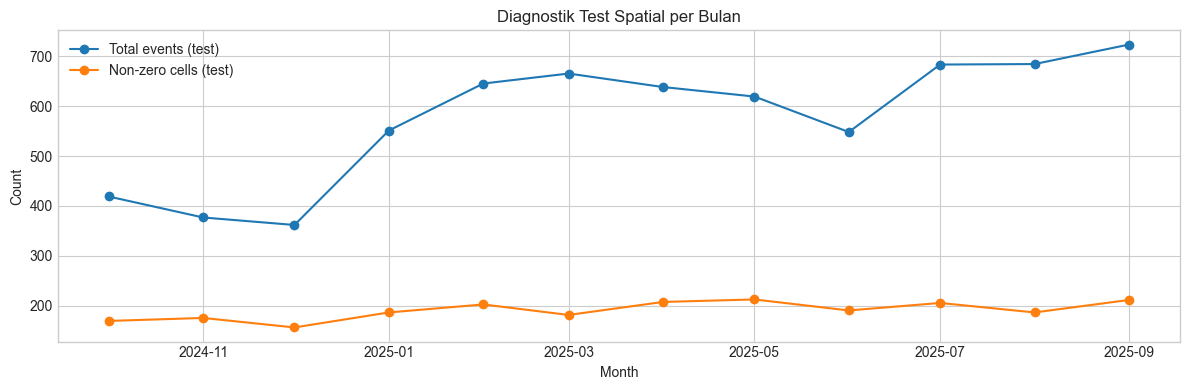

Saved diagnostics:
- D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\diagnostic_distribution.csv
- D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\diagnostic_test_nonzero_by_month.csv
- D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\diagnostic_top_cells_train.csv
- D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\diagnostic_test_monthly_plot.png


In [29]:
# Diagnostik distribusi data train/test spatial
train_diag = train_df.copy()
test_diag = test_df.copy()
train_diag['month'] = pd.to_datetime(train_diag['month'])
test_diag['month'] = pd.to_datetime(test_diag['month'])

def summarize_split(df, split_name):
    cnt = df['count_m3']
    return {
        'split': split_name,
        'rows': int(len(df)),
        'months': int(df['month'].nunique()),
        'cells': int(df['cell_id'].nunique()),
        'nonzero_rows': int((cnt > 0).sum()),
        'zero_ratio': float((cnt == 0).mean()),
        'mean_count': float(cnt.mean()),
        'max_count': float(cnt.max())
    }

diag_distribution = pd.DataFrame([
    summarize_split(train_diag, 'train'),
    summarize_split(test_diag, 'test')
])
display(diag_distribution)

diag_monthly_test = (
    test_diag.assign(is_nonzero=(test_diag['count_m3'] > 0).astype(int))
    .groupby('month', as_index=False)
    .agg(
        total_events=('count_m3', 'sum'),
        nonzero_cells=('is_nonzero', 'sum')
    )
)
display(diag_monthly_test)

diag_top_cells_train = (
    train_diag.groupby(['cell_id', 'lat_bin', 'lon_bin'], as_index=False)['count_m3']
    .sum()
    .rename(columns={'count_m3': 'total_events_train'})
    .sort_values('total_events_train', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(diag_top_cells_train)

diag_distribution.to_csv(ARTIFACT_DIR / 'diagnostic_distribution.csv', index=False)
diag_monthly_test.to_csv(ARTIFACT_DIR / 'diagnostic_test_nonzero_by_month.csv', index=False)
diag_top_cells_train.to_csv(ARTIFACT_DIR / 'diagnostic_top_cells_train.csv', index=False)

plt.figure(figsize=(12, 4))
plt.plot(diag_monthly_test['month'], diag_monthly_test['total_events'], marker='o', label='Total events (test)')
plt.plot(diag_monthly_test['month'], diag_monthly_test['nonzero_cells'], marker='o', label='Non-zero cells (test)')
plt.title('Diagnostik Test Spatial per Bulan')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'diagnostic_test_monthly_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved diagnostics:')
print('-', ARTIFACT_DIR / 'diagnostic_distribution.csv')
print('-', ARTIFACT_DIR / 'diagnostic_test_nonzero_by_month.csv')
print('-', ARTIFACT_DIR / 'diagnostic_top_cells_train.csv')
print('-', ARTIFACT_DIR / 'diagnostic_test_monthly_plot.png')

In [30]:
# Train two-stage model
clf = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=30,
    random_state=42
)

reg = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)

clf.fit(X_train, y_train_occ)
reg.fit(X_train[mask_pos], y_train_cnt[mask_pos])

print('Model trained.')

Model trained.


In [31]:
# Evaluasi test
p_occ_test = clf.predict_proba(X_test)[:, 1]
pred_cnt_if_event_test = np.clip(reg.predict(X_test), 0.0, None)
expected_cnt_test = p_occ_test * pred_cnt_if_event_test

test_pred = test_df[['month', 'cell_id', 'lat_bin', 'lon_bin', 'count_m3']].copy()
test_pred['p_event'] = p_occ_test
test_pred['pred_count_if_event'] = pred_cnt_if_event_test
test_pred['pred_expected_count'] = expected_cnt_test
test_pred['pred_event'] = (test_pred['p_event'] >= 0.5).astype(int)

metrics = {
    'mae_expected_count': float(mean_absolute_error(y_test_cnt, expected_cnt_test)),
    'rmse_expected_count': float(np.sqrt(mean_squared_error(y_test_cnt, expected_cnt_test))),
    'brier_event': float(brier_score_loss(y_test_occ, p_occ_test)),
    'positive_rate_test': float(y_test_occ.mean())
}

if len(np.unique(y_test_occ)) > 1:
    metrics['roc_auc_event'] = float(roc_auc_score(y_test_occ, p_occ_test))
else:
    metrics['roc_auc_event'] = np.nan

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

test_pred.to_csv(ARTIFACT_DIR / 'predictions_test_spatial.csv', index=False)
metrics_df.to_csv(ARTIFACT_DIR / 'metrics_spatial.csv', index=False)

print('Saved test prediction:', ARTIFACT_DIR / 'predictions_test_spatial.csv')
print('Saved metrics:', ARTIFACT_DIR / 'metrics_spatial.csv')

,mae_expected_count,rmse_expected_count,brier_event,positive_rate_test,roc_auc_event
0,0.594414,2.171754,0.088088,0.269014,0.938369


Saved test prediction: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\predictions_test_spatial.csv
Saved metrics: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\metrics_spatial.csv


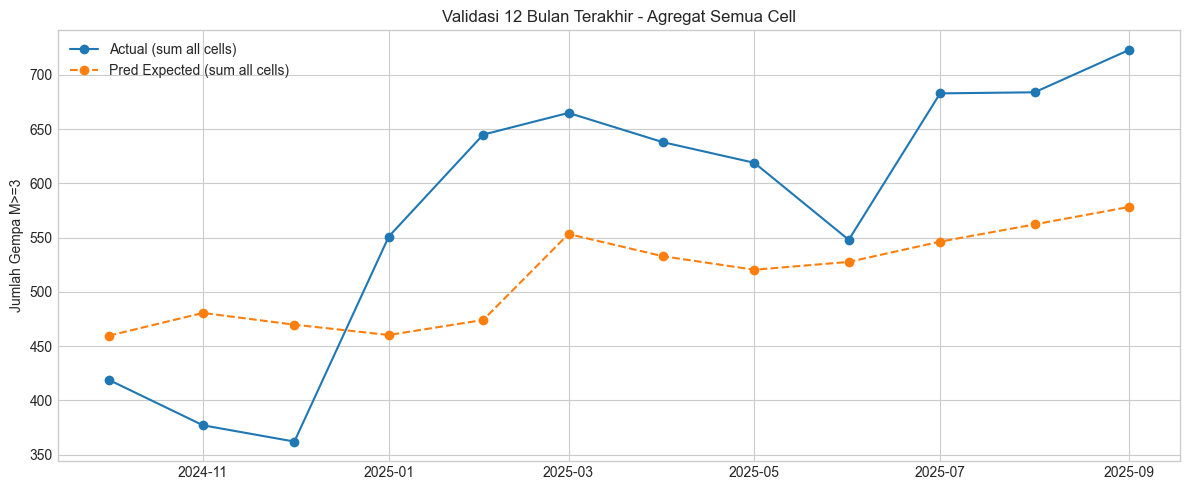

In [32]:
# Visualisasi quick-check agregat per bulan (test)
agg_actual = test_pred.groupby('month')['count_m3'].sum()
agg_expected = test_pred.groupby('month')['pred_expected_count'].sum()

plt.figure(figsize=(12, 5))
plt.plot(agg_actual.index, agg_actual.values, label='Actual (sum all cells)', marker='o')
plt.plot(agg_expected.index, agg_expected.values, label='Pred Expected (sum all cells)', marker='o', linestyle='--')
plt.title('Validasi 12 Bulan Terakhir - Agregat Semua Cell')
plt.ylabel('Jumlah Gempa M>=3')
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'validation_plot_aggregate.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Retrain full-data dan simpan model
X_full = model_df[FEATURE_COLS]
y_full_occ = model_df['is_event']
y_full_cnt = model_df['count_m3']
mask_full_pos = y_full_cnt > 0

clf_full = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=30,
    random_state=42
)

reg_full = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=20,
    random_state=42
)

clf_full.fit(X_full, y_full_occ)
reg_full.fit(X_full[mask_full_pos], y_full_cnt[mask_full_pos])

history_pivot = (
    panel.pivot(index='month', columns='cell_id', values='count_m3')
    .sort_index()
    .astype(float)
)

cell_lookup = panel[['cell_id', 'lat_bin', 'lon_bin']].drop_duplicates().sort_values('cell_id').reset_index(drop=True)

model_bundle = {
    'classifier': clf_full,
    'regressor': reg_full,
    'feature_cols': FEATURE_COLS,
    'lags': LAGS,
    'roll_windows': ROLL_WINDOWS,
    'grid_deg': GRID_DEG,
    'mag_threshold': MAG_THRESHOLD,
    'history_pivot': history_pivot,
    'cell_lookup': cell_lookup,
    'last_observed_month': str(history_pivot.index.max().date())
}

model_path = MODEL_DIR / 'spatial_click_m3_twostage.joblib'
joblib.dump(model_bundle, model_path)

meta = {
    'data_path': str(DATA_PATH),
    'artifact_dir': str(ARTIFACT_DIR),
    'model_path': str(model_path),
    'grid_deg': GRID_DEG,
    'mag_threshold': MAG_THRESHOLD,
    'test_horizon': TEST_HORIZON,
    'feature_cols': FEATURE_COLS,
    'n_cells': int(cell_lookup.shape[0]),
    'n_months': int(history_pivot.shape[0]),
    'metrics_test': metrics
}

with open(ARTIFACT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Saved model:', model_path)
print('Saved metadata:', ARTIFACT_DIR / 'metadata.json')

Saved model: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\saved_models\spatial_click_m3_twostage.joblib
Saved metadata: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_spatial_click_m3\metadata.json


In [34]:
# Fungsi inferensi klik lat/lon -> prediksi 1 bulan ke depan
def latlon_to_bin(lat, lon, grid_deg):
    return int(np.floor(lat / grid_deg)), int(np.floor(lon / grid_deg))

def build_single_feature(lat_bin, lon_bin, target_month, history_series, feature_cols, lags, roll_windows):
    target_month = pd.Timestamp(target_month).to_period('M').to_timestamp()
    feat = {}

    for lag in lags:
        lag_month = (target_month.to_period('M') - lag).to_timestamp()
        feat[f'lag_{lag}'] = float(history_series.get(lag_month, 0.0))

    for w in roll_windows:
        vals = []
        for k in range(1, w + 1):
            m = (target_month.to_period('M') - k).to_timestamp()
            vals.append(float(history_series.get(m, 0.0)))
        feat[f'roll_mean_{w}'] = float(np.mean(vals))
        feat[f'roll_std_{w}'] = float(np.std(vals))

    month_num = target_month.month
    feat['month_sin'] = float(np.sin(2 * np.pi * month_num / 12.0))
    feat['month_cos'] = float(np.cos(2 * np.pi * month_num / 12.0))
    feat['lat_bin'] = int(lat_bin)
    feat['lon_bin'] = int(lon_bin)

    return pd.DataFrame([feat])[feature_cols]

def predict_click_one_month(lat, lon, bundle, reference_month=None):
    grid_deg = bundle['grid_deg']
    lat_bin, lon_bin = latlon_to_bin(lat, lon, grid_deg)
    cell_id = f'{lat_bin}_{lon_bin}'

    history = bundle['history_pivot']

    if reference_month is None:
        ref_month = pd.Timestamp(bundle['last_observed_month']).to_period('M').to_timestamp()
    else:
        ref_month = pd.Timestamp(reference_month).to_period('M').to_timestamp()

    target_month = (ref_month.to_period('M') + 1).to_timestamp()

    if cell_id in history.columns:
        series = history[cell_id]
        known_cell = True
    else:
        series = pd.Series(0.0, index=history.index)
        known_cell = False

    X_row = build_single_feature(
        lat_bin=lat_bin,
        lon_bin=lon_bin,
        target_month=target_month,
        history_series=series,
        feature_cols=bundle['feature_cols'],
        lags=bundle['lags'],
        roll_windows=bundle['roll_windows']
    )

    p_event = float(bundle['classifier'].predict_proba(X_row)[0, 1])
    pred_if_event = float(np.clip(bundle['regressor'].predict(X_row)[0], 0.0, None))
    expected_count = float(p_event * pred_if_event)

    return {
        'input_lat': float(lat),
        'input_lon': float(lon),
        'lat_bin': int(lat_bin),
        'lon_bin': int(lon_bin),
        'cell_id': cell_id,
        'known_cell_in_training': known_cell,
        'reference_month': str(ref_month.date()),
        'target_month': str(target_month.date()),
        'prob_event_ge_1': p_event,
        'pred_count_if_event': pred_if_event,
        'expected_count': expected_count
    }

In [35]:
# Contoh inferensi klik
bundle_loaded = joblib.load(MODEL_DIR / 'spatial_click_m3_twostage.joblib')

# Contoh 1: pakai titik dari data historis
sample_lat = float(df_m3.iloc[0]['latitude'])
sample_lon = float(df_m3.iloc[0]['longitude'])
result_1 = predict_click_one_month(sample_lat, sample_lon, bundle_loaded)

# Contoh 2: titik bebas (ubah sesuai klik dari UI)
clicked_lat = -6.2
clicked_lon = 106.8
result_2 = predict_click_one_month(clicked_lat, clicked_lon, bundle_loaded)

print('Result sample historical point:')
print(json.dumps(result_1, indent=2))

print('\nResult custom clicked point:')
print(json.dumps(result_2, indent=2))

Result sample historical point:
{
  "input_lat": -6.6118598,
  "input_lon": 129.38722,
  "lat_bin": -7,
  "lon_bin": 129,
  "cell_id": "-7_129",
  "known_cell_in_training": true,
  "reference_month": "2025-09-01",
  "target_month": "2025-10-01",
  "prob_event_ge_1": 0.9828657537095813,
  "pred_count_if_event": 5.750970050305771,
  "expected_count": 5.65243151305501
}

Result custom clicked point:
{
  "input_lat": -6.2,
  "input_lon": 106.8,
  "lat_bin": -7,
  "lon_bin": 106,
  "cell_id": "-7_106",
  "known_cell_in_training": true,
  "reference_month": "2025-09-01",
  "target_month": "2025-10-01",
  "prob_event_ge_1": 0.7011727011649891,
  "pred_count_if_event": 2.7771608623932105,
  "expected_count": 1.9472693834539379
}
